# CNN for Plant/Crop Disease Segmentation
### COMP9517 – EWS Dataset

This notebook implements a **U-Net style CNN from scratch** in PyTorch for binary semantic segmentation of plant disease regions.

**Dataset structure expected:**
```
EWS-Dataset/
  train/        ← paired RGB images + _mask.png files
  validation/
  test/
```

**Pipeline:**
1. Custom Dataset + DataLoader
2. CNN architecture (U-Net built from scratch)
3. Training loop with loss + metrics
4. Evaluation on test set
5. Visualisation of predictions

## 1. Imports & Configuration

In [1]:
!pip install torch torchvision --quiet

import os
import re
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# ── Configuration ────────────────────────────────────────────────────────────
DATA_ROOT = 'EWS-Dataset'       # adjust if needed
IMG_SIZE    = 256               # resize all images to 256×256
BATCH_SIZE  = 8
EPOCHS      = 30
LR          = 1e-3
NUM_WORKERS = 0
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Using device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## 2. Dataset

Each folder contains paired files:
- `<ID>.png`        → RGB input image  
- `<ID>_mask.png`   → binary segmentation mask (disease = white, background = black)

In [2]:
class EWSDataset(Dataset):
    """
    Loads paired (image, mask) files from one split folder.
    Masks are binarised: pixel > 127 → 1 (diseased), else → 0 (healthy).
    """

    def __init__(self, root, split='train', img_size=256, augment=False):
        self.folder   = os.path.join(root, split)
        self.img_size = img_size
        self.augment  = augment

        # Collect all non-mask images
        all_files = sorted(os.listdir(self.folder))
        self.images = [
            f for f in all_files
            if f.endswith('.png') and not f.endswith('_mask.png')
        ]

        # Verify every image has a matching mask
        verified = []
        for img_file in self.images:
            stem      = img_file.replace('.png', '')
            mask_file = stem + '_mask.png'
            if os.path.exists(os.path.join(self.folder, mask_file)):
                verified.append(img_file)
            else:
                print(f'[Warning] No mask found for {img_file}, skipping.')
        self.images = verified
        print(f'[{split}] {len(self.images)} image-mask pairs loaded.')

    # ── helpers ──────────────────────────────────────────────────────────────
    def _resize(self, img, is_mask=False):
        mode = Image.NEAREST if is_mask else Image.BILINEAR
        return img.resize((self.img_size, self.img_size), mode)

    def _augment(self, image, mask):
        """Apply identical random transforms to image and mask."""
        # Random horizontal flip
        if torch.rand(1) > 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)
        # Random vertical flip
        if torch.rand(1) > 0.5:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)
        # Random 90° rotation
        k = int(torch.randint(0, 4, (1,)))
        image = TF.rotate(image, k * 90)
        mask  = TF.rotate(mask,  k * 90)
        return image, mask

    # ── Dataset interface ─────────────────────────────────────────────────────
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name  = self.images[idx]
        stem      = img_name.replace('.png', '')
        mask_name = stem + '_mask.png'

        image = Image.open(os.path.join(self.folder, img_name)).convert('RGB')
        mask  = Image.open(os.path.join(self.folder, mask_name)).convert('L')

        image = self._resize(image, is_mask=False)
        mask  = self._resize(mask,  is_mask=True)

        if self.augment:
            image, mask = self._augment(image, mask)

        # Convert to tensors
        image = TF.to_tensor(image)                        # [3, H, W]  float32 in [0,1]
        image = TF.normalize(image,
                              mean=[0.485, 0.456, 0.406],
                              std =[0.229, 0.224, 0.225])  # ImageNet stats

        mask  = torch.from_numpy(np.array(mask))           # [H, W]  uint8
        mask  = (mask > 127).long()                        # binarise → {0, 1}

        return image, mask


# ── Instantiate datasets ──────────────────────────────────────────────────────
train_ds = EWSDataset(DATA_ROOT, split='train',      img_size=IMG_SIZE, augment=True)
val_ds   = EWSDataset(DATA_ROOT, split='validation', img_size=IMG_SIZE, augment=False)
test_ds  = EWSDataset(DATA_ROOT, split='test',       img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

[train] 142 image-mask pairs loaded.
[validation] 24 image-mask pairs loaded.
[test] 24 image-mask pairs loaded.


### 2.1 Visualise a Sample Batch

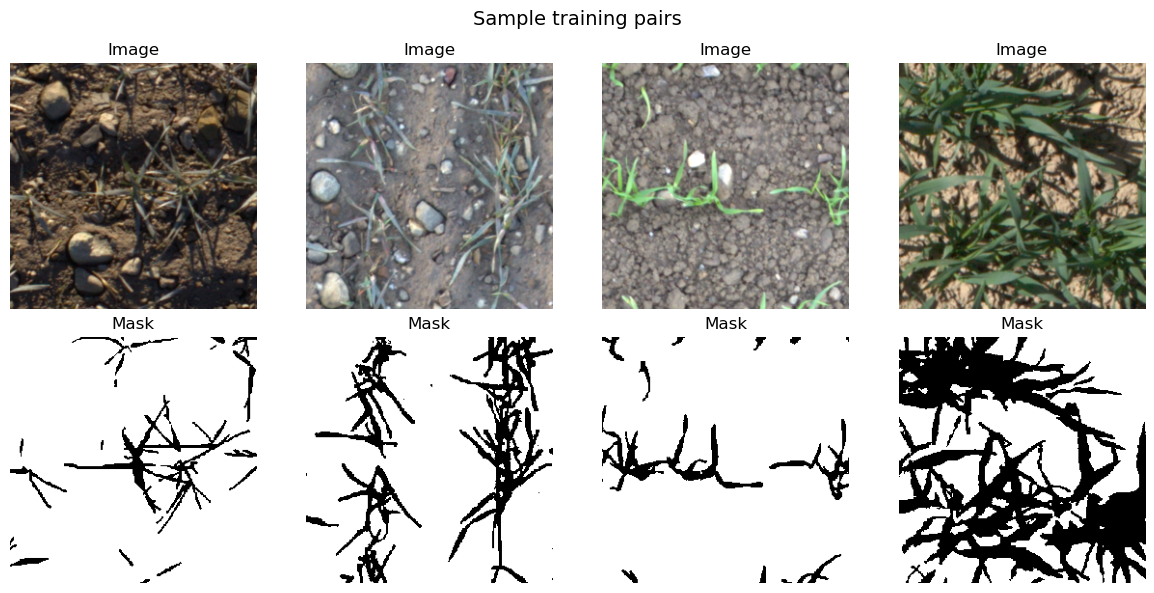

In [3]:
def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

images, masks = next(iter(train_loader))
n = min(4, len(images))

fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
for i in range(n):
    img = denormalise(images[i]).permute(1,2,0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title('Image')
    axes[0, i].axis('off')

    axes[1, i].imshow(masks[i].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Mask')
    axes[1, i].axis('off')

plt.suptitle('Sample training pairs', fontsize=14)
plt.tight_layout()
plt.show()

## 3. CNN Architecture — U-Net from Scratch

U-Net uses an **encoder–decoder** design with **skip connections**:

```
Input (3×256×256)
  │
  ├─ Encoder Block 1 (64)  ──────────────────────────┐ skip
  ├─ Encoder Block 2 (128) ─────────────────────┐ skip│
  ├─ Encoder Block 3 (256) ────────────────┐ skip│    │
  ├─ Encoder Block 4 (512) ──────────┐ skip│    │    │
  │                                   │    │    │    │
  └─ Bottleneck (1024)                │    │    │    │
                                      │    │    │    │
  ┌─ Decoder Block 4 (512) ◄──────────┘    │    │    │
  ├─ Decoder Block 3 (256) ◄───────────────┘    │    │
  ├─ Decoder Block 2 (128) ◄────────────────────┘    │
  ├─ Decoder Block 1 (64)  ◄─────────────────────────┘
  │
  └─ Output Conv (1×256×256) → sigmoid
```

In [4]:
# ── Building block: two conv layers with BatchNorm + ReLU ─────────────────────
class DoubleConv(nn.Module):
    """
    Conv(3×3) → BN → ReLU → Conv(3×3) → BN → ReLU
    This is the fundamental unit repeated throughout U-Net.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# ── Encoder block: DoubleConv + MaxPool ───────────────────────────────────────
class EncoderBlock(nn.Module):
    """
    Applies DoubleConv, saves the result as a skip connection,
    then downsamples with MaxPool(2×2).
    Returns: (pooled output, skip feature map)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)    # full-resolution feature map
        down = self.pool(skip) # halved spatial dimensions
        return down, skip


# ── Decoder block: Upsample + concatenate skip + DoubleConv ───────────────────
class DecoderBlock(nn.Module):
    """
    Upsamples by 2× (bilinear), concatenates the skip connection
    from the corresponding encoder, then applies DoubleConv.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # in_channels = upsampled channels + skip channels
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        # Handle odd input sizes: pad if necessary
        if x.shape != skip.shape:
            x = F.pad(x, [0, skip.shape[3]-x.shape[3],
                          0, skip.shape[2]-x.shape[2]])
        x = torch.cat([skip, x], dim=1)  # concatenate along channel dim
        return self.conv(x)


# ── Full U-Net ─────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    """
    U-Net for binary semantic segmentation.

    Args:
        in_channels  : number of input image channels (3 for RGB)
        out_channels : number of output classes (1 for binary segmentation)
        features     : list of channel sizes at each encoder level
    """
    def __init__(self, in_channels=3, out_channels=1,
                 features=[64, 128, 256, 512]):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.encoders = nn.ModuleList()
        prev = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(prev, f))
            prev = f

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # ── Decoder ──────────────────────────────────────────────────────────
        self.decoders = nn.ModuleList()
        rev = list(reversed(features))
        prev = features[-1] * 2        # bottleneck output
        for f in rev:
            # prev (up) + f (skip) → f
            self.decoders.append(DecoderBlock(prev + f, f))
            prev = f

        # ── Output head ──────────────────────────────────────────────────────
        self.output_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []

        # Encoder path
        for enc in self.encoders:
            x, skip = enc(x)
            skips.append(skip)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder path (reverse skip connections)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)

        return self.output_conv(x)   # raw logits [B, 1, H, W]


# ── Instantiate & inspect ─────────────────────────────────────────────────────
model = UNet(in_channels=3, out_channels=1).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

# Quick forward-pass sanity check
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input shape:  {dummy.shape}')
print(f'Output shape: {out.shape}')   # should be [2, 1, 256, 256]

Total trainable parameters: 31,384,833
Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])


## 4. Loss Function & Metrics

We combine **Binary Cross-Entropy** (pixel-wise classification) with **Dice Loss** (optimises overlap directly — better for imbalanced masks).

In [5]:
class DiceLoss(nn.Module):
    """
    Dice Loss = 1 - (2 * |P ∩ G|) / (|P| + |G|)
    Measures overlap between predicted and ground-truth mask.
    Particularly useful when disease regions are small (class imbalance).
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits)          # [B, 1, H, W]
        targets = targets.unsqueeze(1).float()   # [B, 1, H, W]

        intersection = (probs * targets).sum(dim=(2,3))
        union        = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    """Weighted combination of BCE and Dice loss."""
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        bce_loss  = self.bce(logits, targets.unsqueeze(1).float())
        dice_loss = self.dice(logits, targets)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


# ── Evaluation metrics ────────────────────────────────────────────────────────
def compute_metrics(logits, targets, threshold=0.5):
    """
    Returns pixel accuracy, IoU (Jaccard), and Dice coefficient.
    logits  : [B, 1, H, W] raw model output
    targets : [B, H, W]    binary ground truth
    """
    preds   = (torch.sigmoid(logits) > threshold).squeeze(1).long()  # [B,H,W]
    targets = targets.long()

    # Pixel accuracy
    acc = (preds == targets).float().mean().item()

    # IoU
    intersection = (preds & targets).float().sum().item()
    union        = (preds | targets).float().sum().item()
    iou  = (intersection + 1e-6) / (union + 1e-6)

    # Dice
    dice = (2 * intersection + 1e-6) / (preds.float().sum().item() +
                                         targets.float().sum().item() + 1e-6)
    return acc, iou, dice


criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=LR)
# Reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  patience=5, factor=0.5)
print('Loss, optimizer, and scheduler ready.')

Loss, optimizer, and scheduler ready.


## 5. Training Loop

In [6]:
def run_epoch(loader, model, criterion, optimizer=None, desc='Train'):
    """
    Runs one full pass over a dataloader.
    If optimizer is provided, performs backprop (training mode).
    Otherwise runs in eval mode (validation/test).
    Returns: avg_loss, avg_accuracy, avg_iou, avg_dice
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_acc, total_iou, total_dice = 0, 0, 0, 0

    context = torch.enable_grad if is_train else torch.no_grad
    with context():
        for images, masks in loader:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)

            logits = model(images)           # forward pass
            loss   = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()              # backprop
                optimizer.step()

            acc, iou, dice = compute_metrics(logits, masks)
            total_loss += loss.item()
            total_acc  += acc
            total_iou  += iou
            total_dice += dice

    n = len(loader)
    return total_loss/n, total_acc/n, total_iou/n, total_dice/n


# ── Training ──────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_iou':  [], 'val_iou':  [],
           'train_dice': [], 'val_dice': []}

best_val_loss = float('inf')
best_model_path = 'best_unet.pth'

print(f'Training for {EPOCHS} epochs on {DEVICE}...')
print('-' * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc, tr_iou, tr_dice = run_epoch(train_loader, model, criterion, optimizer, 'Train')
    vl_loss, vl_acc, vl_iou, vl_dice = run_epoch(val_loader,   model, criterion, None,      'Val')

    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(vl_iou)
    history['train_dice'].append(tr_dice)
    history['val_dice'].append(vl_dice)

    # Save best model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), best_model_path)
        tag = ' ← best'
    else:
        tag = ''

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:>3}/{EPOCHS}]  '
          f'Loss: {tr_loss:.4f}/{vl_loss:.4f}  '
          f'IoU: {tr_iou:.4f}/{vl_iou:.4f}  '
          f'Dice: {tr_dice:.4f}/{vl_dice:.4f}  '
          f'({elapsed:.1f}s){tag}')

print('-' * 70)
print(f'Best val loss: {best_val_loss:.4f} — saved to {best_model_path}')

Training for 30 epochs on cpu...
----------------------------------------------------------------------
Epoch [  1/30]  Loss: 0.2734/0.7881  IoU: 0.8597/0.6275  Dice: 0.9237/0.7701  (133.4s) ← best
Epoch [  2/30]  Loss: 0.1790/0.1890  IoU: 0.9072/0.9017  Dice: 0.9511/0.9483  (151.8s) ← best
Epoch [  3/30]  Loss: 0.1531/0.1499  IoU: 0.9146/0.9066  Dice: 0.9553/0.9510  (124.9s) ← best
Epoch [  4/30]  Loss: 0.1391/0.1433  IoU: 0.9197/0.9099  Dice: 0.9581/0.9528  (133.5s) ← best
Epoch [  5/30]  Loss: 0.1300/0.1621  IoU: 0.9203/0.8895  Dice: 0.9584/0.9415  (140.6s)
Epoch [  6/30]  Loss: 0.1268/0.1463  IoU: 0.9211/0.9000  Dice: 0.9589/0.9473  (136.0s)
Epoch [  7/30]  Loss: 0.1259/0.1388  IoU: 0.9210/0.9076  Dice: 0.9587/0.9516  (143.9s) ← best
Epoch [  8/30]  Loss: 0.1180/0.1692  IoU: 0.9249/0.8809  Dice: 0.9609/0.9367  (276.9s)
Epoch [  9/30]  Loss: 0.1192/0.1388  IoU: 0.9242/0.9026  Dice: 0.9605/0.9488  (350.6s) ← best
Epoch [ 10/30]  Loss: 0.1258/0.1484  IoU: 0.9177/0.8980  Dice: 0.9570/0

## 6. Training Curves

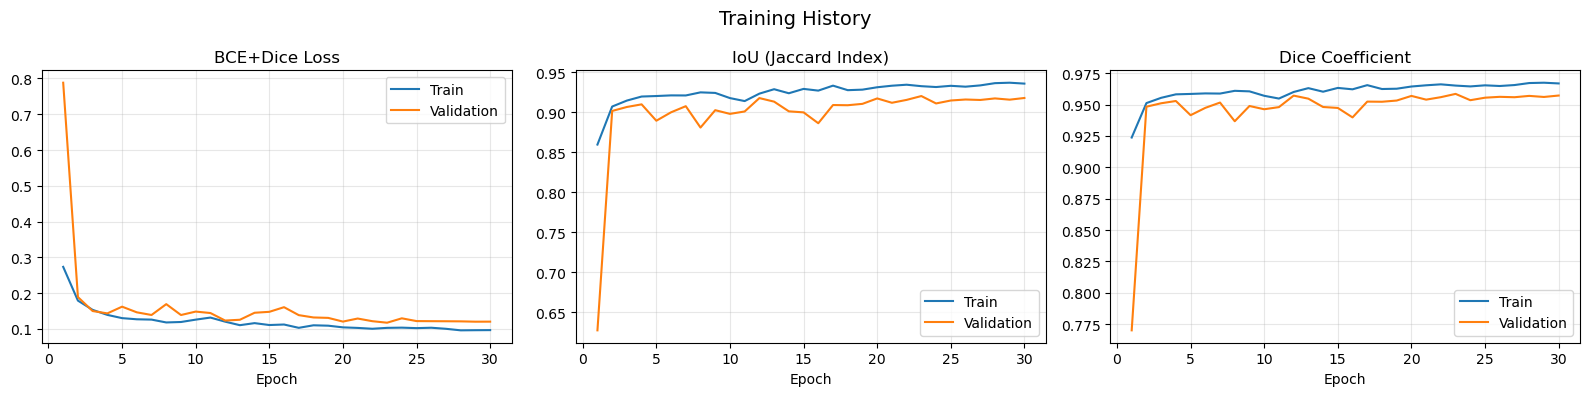

In [7]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Validation')
axes[0].set_title('BCE+Dice Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_iou'], label='Train')
axes[1].plot(epochs_range, history['val_iou'],   label='Validation')
axes[1].set_title('IoU (Jaccard Index)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['train_dice'], label='Train')
axes[2].plot(epochs_range, history['val_dice'],   label='Validation')
axes[2].set_title('Dice Coefficient')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Test Set Evaluation

In [8]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

test_loss, test_acc, test_iou, test_dice = run_epoch(test_loader, model, criterion, None, 'Test')

print('=' * 45)
print('TEST SET RESULTS')
print('=' * 45)
print(f'  Loss            : {test_loss:.4f}')
print(f'  Pixel Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  IoU (Jaccard)   : {test_iou:.4f}')
print(f'  Dice Coefficient: {test_dice:.4f}')
print('=' * 45)

TEST SET RESULTS
  Loss            : 0.1270
  Pixel Accuracy  : 0.9354  (93.54%)
  IoU (Jaccard)   : 0.9081
  Dice Coefficient: 0.9518


## 8. Visualise Predictions

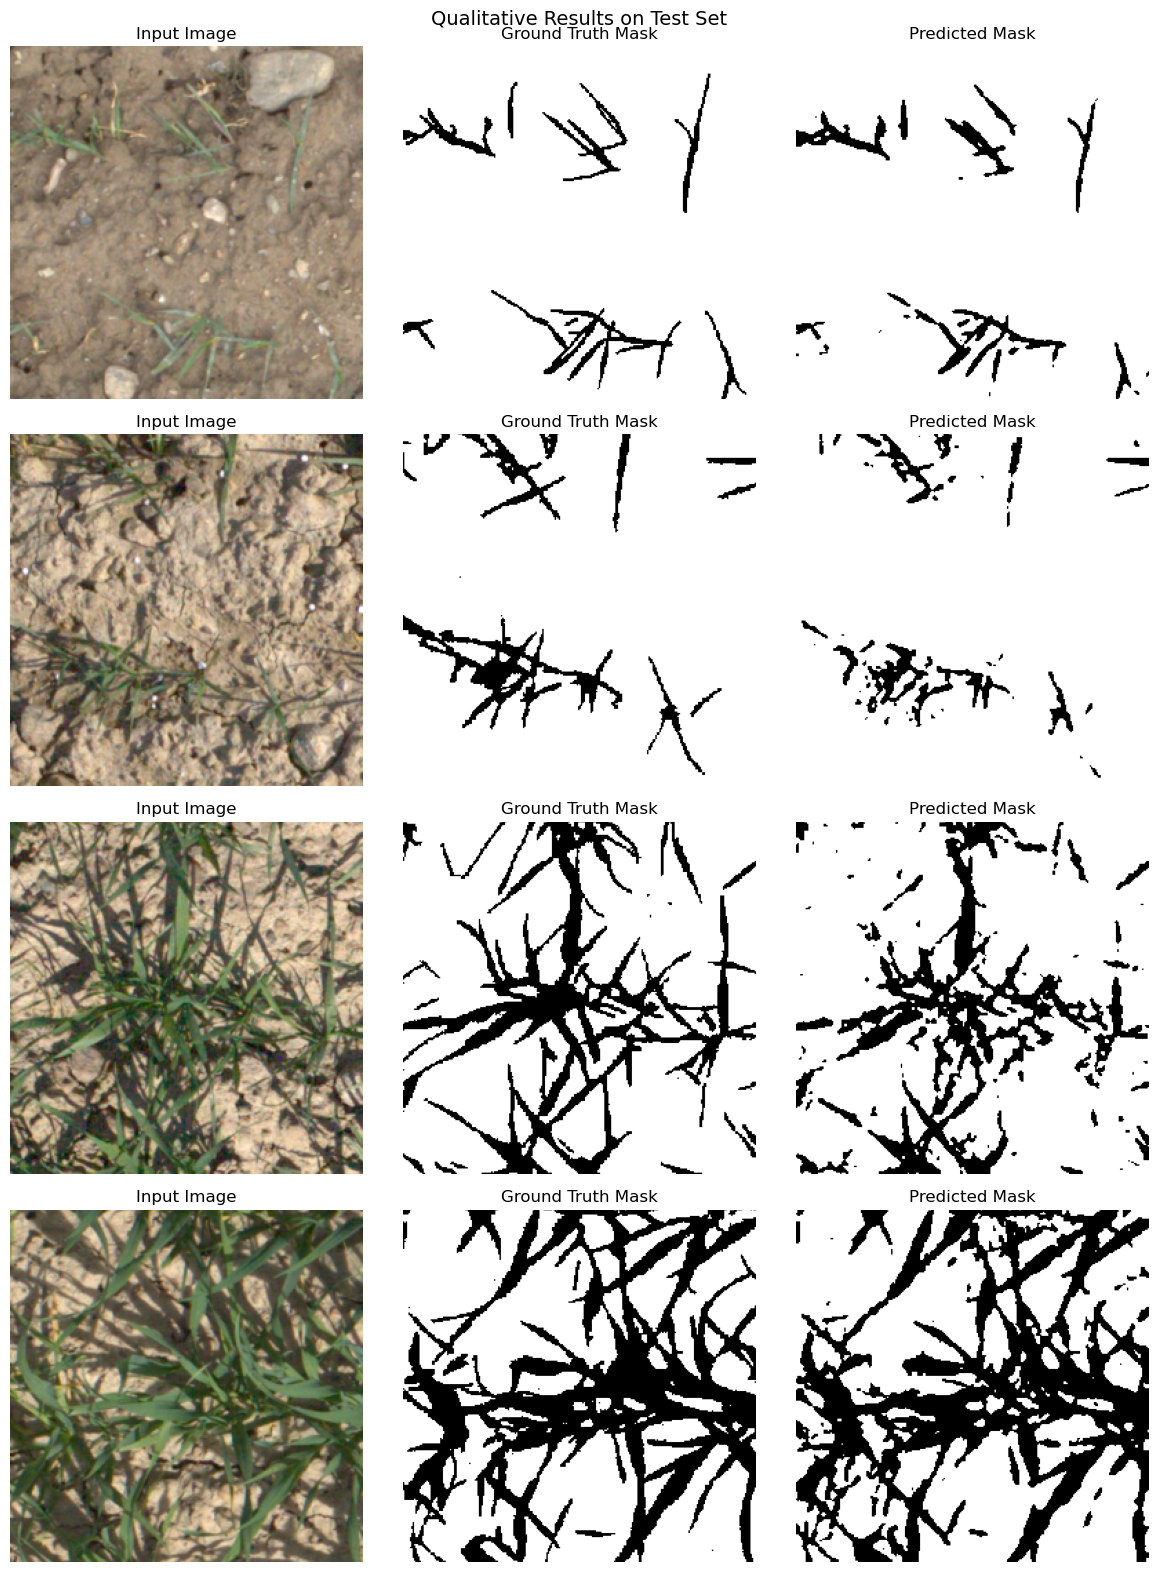

In [9]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    logits = model(images)
    preds  = (torch.sigmoid(logits) > 0.5).squeeze(1).cpu().numpy()  # [B,H,W] bool

images = images.cpu()
masks  = masks.numpy()

n = min(4, len(images))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
if n == 1:
    axes = axes[np.newaxis, :]

for i in range(n):
    img = denormalise(images[i]).permute(1,2,0).numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Input Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(masks[i], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(preds[i], cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')

plt.suptitle('Qualitative Results on Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.5 Performance Metrics Summary

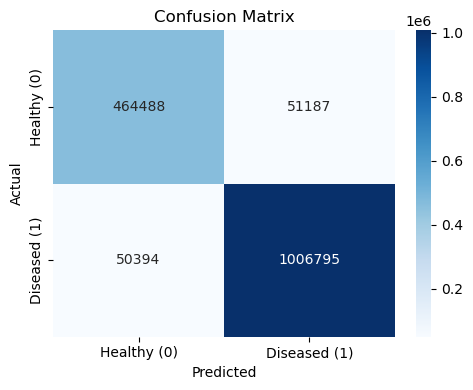

FULL TEST SET PERFORMANCE METRICS
  Pixel Accuracy  : 0.9354  (93.54%)
  Precision       : 0.9516
  Recall (Sensitivity): 0.9523
  Specificity     : 0.9007
  F1 Score        : 0.9520
  IoU (Jaccard)   : 0.9084
  Dice Coefficient: 0.9520

  Confusion Matrix breakdown:
    TP=1006795  FP=51187
    FN=50394  TN=464488

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.90      0.90      0.90    515675
    Diseased       0.95      0.95      0.95   1057189

    accuracy                           0.94   1572864
   macro avg       0.93      0.93      0.93   1572864
weighted avg       0.94      0.94      0.94   1572864



In [10]:
## Performance Metrics Summary

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Collect all predictions and ground truths over the full test set ──────────
all_preds   = []
all_targets = []

model.eval()
with torch.no_grad():
    for imgs, msks in test_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        pred   = (torch.sigmoid(logits) > 0.5).squeeze(1).cpu().numpy()
        all_preds.append(pred.flatten())
        all_targets.append(msks.numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(all_targets, all_preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Diseased (1)'],
            yticklabels=['Healthy (0)', 'Diseased (1)'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Derived metrics from confusion matrix ──────────────────────────────────
precision  = tp / (tp + fp + 1e-6)
recall     = tp / (tp + fn + 1e-6)   # same as sensitivity
specificity = tn / (tn + fp + 1e-6)
f1         = 2 * precision * recall / (precision + recall + 1e-6)
iou        = tp / (tp + fp + fn + 1e-6)
dice       = 2 * tp / (2 * tp + fp + fn + 1e-6)
pixel_acc  = (tp + tn) / (tp + tn + fp + fn)

print('=' * 45)
print('FULL TEST SET PERFORMANCE METRICS')
print('=' * 45)
print(f'  Pixel Accuracy  : {pixel_acc:.4f}  ({pixel_acc*100:.2f}%)')
print(f'  Precision       : {precision:.4f}')
print(f'  Recall (Sensitivity): {recall:.4f}')
print(f'  Specificity     : {specificity:.4f}')
print(f'  F1 Score        : {f1:.4f}')
print(f'  IoU (Jaccard)   : {iou:.4f}')
print(f'  Dice Coefficient: {dice:.4f}')
print('=' * 45)
print(f'\n  Confusion Matrix breakdown:')
print(f'    TP={tp}  FP={fp}')
print(f'    FN={fn}  TN={tn}')

# ── 3. Per-class classification report ───────────────────────────────────────
print('\nClassification Report:')
print(classification_report(all_targets, all_preds,
                             target_names=['Healthy', 'Diseased']))

## 9. Overlay Predictions on Original Images

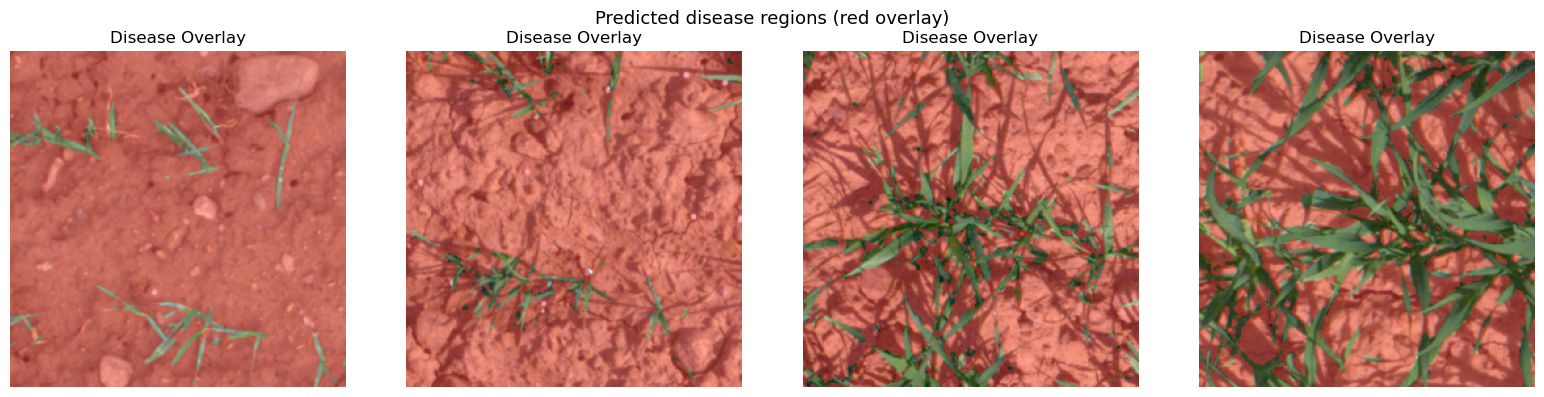

In [11]:
def overlay_mask(image_tensor, pred_mask, color=(1.0, 0.2, 0.2), alpha=0.4):
    """
    Overlays the predicted disease mask in red over the original image.
    Returns an RGB numpy array.
    """
    img = denormalise(image_tensor).permute(1,2,0).numpy().copy()
    overlay = img.copy()
    mask = pred_mask.astype(bool)
    for c, col in enumerate(color):
        overlay[:, :, c][mask] = col
    return (1 - alpha) * img + alpha * overlay

n = min(4, len(images))
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]

for i in range(n):
    blended = overlay_mask(images[i], preds[i])
    axes[i].imshow(blended)
    axes[i].set_title('Disease Overlay')
    axes[i].axis('off')

plt.suptitle('Predicted disease regions (red overlay)', fontsize=13)
plt.tight_layout()
plt.savefig('overlays.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Final Model

In [12]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'config': {
        'img_size': IMG_SIZE,
        'epochs': EPOCHS,
        'lr': LR,
        'batch_size': BATCH_SIZE,
    },
    'test_metrics': {
        'loss': test_loss,
        'accuracy': test_acc,
        'iou': test_iou,
        'dice': test_dice,
    }
}, 'unet_final.pth')

print('Model and training history saved to unet_final.pth')

Model and training history saved to unet_final.pth
